# Evaluate ANC Notebook Script
Final single-control evaluation recipe aligned with the updated training notebook:
- x_p = [gcc_phat, psd_features]
- x_s = path_features -> training checkpoint x_s PCA transform
- model predicts latent target coefficients
- latent coefficients are decoded back to raw truncated W targets before AI-init CFxLMS



In [5]:
from pathlib import Path
import importlib.util
import json
import os
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def _find_repo_root(marker="python_impl/python_scripts/build_cfxlms_qc_dataset.py") -> Path:
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not locate repository root from current working directory. Missing marker: {marker}")


ROOT = _find_repo_root()
os.chdir(ROOT)
if str(ROOT / "python_impl") not in sys.path:
    sys.path.insert(0, str(ROOT / "python_impl"))
print("Project root:", ROOT)

from py_anc.algorithms import cfxlms as cfxlms_fn
from py_anc.utils import wn_gen
from python_scripts.single_control_anc_common import (
    PCAProjector,
    SingleControlANCNet,
    destandardize_array,
    standardize_array,
)


def _resolve_h5_path(explicit_path: str | None = None) -> Path:
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path))
    env_path = os.environ.get("ANC_H5_PATH")
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend(
        [
            Path("python_impl") / "python_scripts" / "cfxlms_qc_dataset_single_control.h5",
            Path("python_impl") / "python_scripts" / "cfxlms_qc_dataset_single_control_500_seeded.h5",
        ]
    )
    checked: list[str] = []
    for candidate in candidates:
        resolved = candidate if candidate.is_absolute() else (ROOT / candidate).resolve()
        checked.append(str(resolved))
        if resolved.exists():
            return resolved
    raise FileNotFoundError(
        "Single-control dataset HDF5 was not found. "
        "Generate python_impl/python_scripts/cfxlms_qc_dataset_single_control.h5 "
        f"or set ANC_H5_PATH. Checked: {checked}"
    )


def _resolve_checkpoint_path(explicit_path: str | None = None) -> Path:
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path))
    env_path = os.environ.get("ANC_CKPT_PATH")
    if env_path:
        candidates.append(Path(env_path))
    candidates.append(Path("best_mimo_anc_net_single_control.pth"))
    checked: list[str] = []
    for candidate in candidates:
        resolved = candidate if candidate.is_absolute() else (ROOT / candidate).resolve()
        checked.append(str(resolved))
        if resolved.exists():
            return resolved
    raise FileNotFoundError(
        "Checkpoint was not found. Train first or set ANC_CKPT_PATH. "
        f"Checked: {checked}"
    )


def _normalize_columns(x_arr: np.ndarray) -> np.ndarray:
    denom = np.max(np.abs(x_arr), axis=0, keepdims=True)
    denom = np.where(denom < np.finfo(float).eps, 1.0, denom)
    return x_arr / denom


def _trim_response(resp: np.ndarray, keep_len: int) -> np.ndarray:
    arr = np.asarray(resp, dtype=np.float32).reshape(-1)
    out = np.zeros((int(keep_len),), dtype=np.float32)
    keep = min(int(keep_len), arr.size)
    if keep > 0:
        out[:keep] = arr[:keep]
    return out


def _resolve_feature_window_start(total_samples: int, cfg, preferred_idx: int | None = None) -> int:
    window = int(cfg.ref_window_samples)
    latest_start = max(total_samples - window, 0)
    start_min = int(round(float(cfg.warmup_start_s_min) * float(cfg.fs)))
    start_max = min(int(round(float(cfg.warmup_start_s_max) * float(cfg.fs))), latest_start)
    if preferred_idx is not None:
        return max(0, min(int(preferred_idx), latest_start))
    if start_max < start_min:
        return 0
    return int((start_min + start_max) // 2)


def _parse_indices(s: str, n_rooms: int) -> list[int]:
    s = s.strip()
    if s.startswith("first:"):
        k = int(s.split(":", 1)[1])
        return list(range(min(k, n_rooms)))
    out: list[int] = []
    for token in s.split(","):
        token = token.strip()
        if not token:
            continue
        if "-" in token:
            a, b = token.split("-", 1)
            out.extend(range(int(a), int(b) + 1))
        else:
            out.append(int(token))
    return [v for v in out if 0 <= v < n_rooms]


def _rolling_mse_db(sig: np.ndarray, fs: int, window_samples: int = 500):
    sig = np.asarray(sig, dtype=float).reshape(-1)
    n = sig.size
    if n < window_samples:
        mse = float(np.mean(sig**2))
        return np.array([0.0]), np.array([10.0 * np.log10(mse + np.finfo(float).eps)])
    kernel = np.ones(window_samples, dtype=float) / float(window_samples)
    pow_s = np.convolve(sig**2, kernel, mode="valid")
    t = (np.arange(len(pow_s)) + (window_samples - 1)) / float(fs)
    return t, 10.0 * np.log10(pow_s + np.finfo(float).eps)


def _build_feature_vector(s_path, e2r_paths, s2r_paths, keep_meta):
    return np.concatenate(
        [
            _trim_response(s_path, keep_meta["s_keep_len"]),
            np.concatenate([_trim_response(r, keep_meta["e2r_keep_len"]) for r in e2r_paths], axis=0),
            np.concatenate([_trim_response(r, keep_meta["s2r_keep_len"]) for r in s2r_paths], axis=0),
        ],
        axis=0,
    ).astype(np.float32)


def _target_to_w_full(target: np.ndarray, num_refs: int, w_keep_len: int, filter_len: int) -> np.ndarray:
    arr = np.asarray(target, dtype=np.float32).reshape(num_refs, w_keep_len)
    w_full = np.zeros((1, num_refs, filter_len), dtype=np.float32)
    w_full[0, :, :w_keep_len] = arr
    return w_full


def _build_weight_tensor_from_w_full(w_full: np.ndarray, filter_len: int, n_ref: int, n_sec: int) -> np.ndarray:
    w = np.zeros((filter_len, n_ref, n_sec), dtype=float)
    arr = np.asarray(w_full, dtype=float)
    for k in range(min(n_sec, arr.shape[0])):
        keep_ref = min(n_ref, arr.shape[1])
        keep_len = min(filter_len, arr.shape[2])
        w[:keep_len, :keep_ref, k] = arr[k, :keep_ref, :keep_len].T
    return w


def cfxlms_with_init(time, rir_manager, L, mu, reference_signal, desired_signal, w_init=None, normalized_update=False, norm_epsilon=1.0e-8):
    x = np.asarray(reference_signal, dtype=float)
    d = np.asarray(desired_signal, dtype=float)
    key_sec_spks = list(rir_manager.secondary_speakers.keys())
    key_err_mics = list(rir_manager.error_microphones.keys())
    num_ref_mics = len(rir_manager.reference_microphones)
    num_sec_spks = len(key_sec_spks)
    num_err_mics = len(key_err_mics)
    n_samples = len(time)

    s_paths = [[None for _ in range(num_err_mics)] for _ in range(num_sec_spks)]
    s_lens = np.zeros((num_sec_spks, num_err_mics), dtype=np.int32)
    max_ls_hat = 0
    for k, sec_id in enumerate(key_sec_spks):
        for m, err_id in enumerate(key_err_mics):
            s = np.asarray(rir_manager.get_secondary_rir(sec_id, err_id), dtype=float)
            s_paths[k][m] = s
            s_lens[k, m] = int(s.size)
            max_ls_hat = max(max_ls_hat, int(s.size))

    w = np.zeros((L, num_ref_mics, num_sec_spks), dtype=float) if w_init is None else _build_weight_tensor_from_w_full(w_init, L, num_ref_mics, num_sec_spks)
    x_taps = np.zeros((max(L, max_ls_hat), num_ref_mics), dtype=float)
    xf_taps = np.zeros((L, num_ref_mics, num_sec_spks, num_err_mics), dtype=float)
    e = np.zeros((n_samples, num_err_mics), dtype=float)
    y_taps = [np.zeros(int(np.max(s_lens[k])), dtype=float) for k in range(num_sec_spks)]

    for n in range(n_samples):
        x_taps[1:, :] = x_taps[:-1, :]
        x_taps[0, :] = x[n, :]
        for k in range(num_sec_spks):
            y = np.sum(w[:, :, k] * x_taps[:L, :])
            y_taps[k][1:] = y_taps[k][:-1]
            y_taps[k][0] = y
        for m in range(num_err_mics):
            yf = 0.0
            for k in range(num_sec_spks):
                s = s_paths[k][m]
                yf += float(np.dot(s, y_taps[k][: int(s_lens[k, m])]))
            e[n, m] = d[n, m] + yf
        xf_taps[1:, :, :, :] = xf_taps[:-1, :, :, :]
        for k in range(num_sec_spks):
            for m in range(num_err_mics):
                s = s_paths[k][m]
                xf_taps[0, :, k, m] = s @ x_taps[: int(s_lens[k, m]), :]
        for k in range(num_sec_spks):
            grad_k = np.zeros((L, num_ref_mics), dtype=float)
            for m in range(num_err_mics):
                phi = xf_taps[:, :, k, m]
                if normalized_update:
                    grad_k += (phi * e[n, m]) / (float(np.sum(phi * phi)) + norm_epsilon)
                else:
                    grad_k += phi * e[n, m]
            w[:, :, k] = w[:, :, k] - mu * grad_k

    filter_coeffs = {sec_id: w[:, :, k].copy() for k, sec_id in enumerate(key_sec_spks)}
    return {"err_hist": e, "filter_coeffs": filter_coeffs}


def _validate_processed_meta(cfg, keep_meta: dict[str, int]) -> None:
    expected_path_feature_dim = (
        int(keep_meta["s_keep_len"])
        + int(cfg.num_reference_mics) * int(keep_meta["e2r_keep_len"])
        + int(cfg.num_reference_mics) * int(keep_meta["s2r_keep_len"])
    )
    expected_w_target_dim = int(cfg.num_reference_mics) * int(keep_meta["w_keep_len"])
    if int(keep_meta["path_feature_dim"]) != expected_path_feature_dim:
        raise ValueError(f"processed/path_feature_dim mismatch: HDF5={keep_meta['path_feature_dim']}, expected={expected_path_feature_dim}")
    if int(keep_meta["w_target_dim"]) != expected_w_target_dim:
        raise ValueError(f"processed/w_target_dim mismatch: HDF5={keep_meta['w_target_dim']}, expected={expected_w_target_dim}")
    if int(keep_meta["w_keep_len"]) > int(cfg.filter_len):
        raise ValueError(f"w_keep_len={keep_meta['w_keep_len']} exceeds filter_len={cfg.filter_len}.")
    if int(keep_meta["gcc_len"]) != int(keep_meta["psd_len"]):
        raise ValueError(f"gcc/psd width mismatch: gcc_len={keep_meta['gcc_len']}, psd_len={keep_meta['psd_len']}")




Project root: z:\anc\distributed_anc_sim_py


In [6]:
builder_path = Path("python_impl") / "python_scripts" / "build_cfxlms_qc_dataset.py"
spec = importlib.util.spec_from_file_location("build_cfx", str(builder_path))
build_mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = build_mod
spec.loader.exec_module(build_mod)

h5_path = _resolve_h5_path()
ckpt_path = _resolve_checkpoint_path()
with h5py.File(str(h5_path), "r") as hf:
    cfg = build_mod.DatasetBuildConfig(**json.loads(hf.attrs["config_json"]))
    keep_meta = {
        "s_keep_len": int(hf["processed"].attrs["s_keep_len"]),
        "e2r_keep_len": int(hf["processed"].attrs["e2r_keep_len"]),
        "s2r_keep_len": int(hf["processed"].attrs["s2r_keep_len"]),
        "w_keep_len": int(hf["processed"].attrs["w_keep_len"]),
        "path_feature_dim": int(hf["processed"].attrs["path_feature_dim"]),
        "w_target_dim": int(hf["processed"].attrs["w_target_dim"]),
        "gcc_len": int(hf["processed/gcc_phat"].shape[-1]),
        "psd_len": int(hf["processed/psd_features"].shape[-1]),
    }
_validate_processed_meta(cfg, keep_meta)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state = torch.load(str(ckpt_path), map_location=device)
x_p_stats = state["x_p_stats"]
x_s_stats = state["x_s_stats"]
y_stats = state["y_stats"]
x_s_projector = PCAProjector.from_state_dict(state["x_s_transform"])
y_projector = PCAProjector.from_state_dict(state["target_transform"])
model_meta = state.get(
    "model_meta",
    {
        "x_s_pca_dim": int(x_s_projector.output_dim),
        "y_latent_dim": int(y_projector.output_dim),
        "dropout": 0.15,
        "monitor": state.get("monitor", "val_raw_mse"),
    },
)

if int(np.asarray(x_p_stats["mean"]).shape[0]) != 4:
    raise ValueError("Checkpoint x_p stats channel dimension must be 4.")
if int(np.asarray(x_s_stats["mean"]).size) != int(keep_meta["path_feature_dim"]):
    raise ValueError("Checkpoint x_s stats do not match HDF5 path_feature_dim.")
if int(np.asarray(y_stats["mean"]).size) != int(keep_meta["w_target_dim"]):
    raise ValueError("Checkpoint y stats do not match HDF5 w_target_dim.")
if int(x_s_projector.input_dim) != int(keep_meta["path_feature_dim"]):
    raise ValueError("Checkpoint x_s PCA input_dim does not match HDF5 path_feature_dim.")
if int(y_projector.input_dim) != int(keep_meta["w_target_dim"]):
    raise ValueError("Checkpoint target PCA input_dim does not match HDF5 w_target_dim.")

trained_on_h5 = state.get("dataset_h5")
if trained_on_h5:
    print("Checkpoint dataset:", trained_on_h5)
    if Path(trained_on_h5).resolve() != h5_path.resolve():
        print("Warning: checkpoint dataset path differs from current evaluation HDF5. Dimension checks passed, but room replay will use the current HDF5.")

model = SingleControlANCNet(x_s_dim=x_s_projector.output_dim, latent_dim=y_projector.output_dim, dropout=float(model_meta.get("dropout", 0.15))).to(device)
model.load_state_dict(state["model_state_dict"])
model.eval()
print("Loaded checkpoint:", ckpt_path, "device:", device)
print("HDF5 dataset:", h5_path)
print("keep_meta:", keep_meta)
print("x_s PCA dim:", x_s_projector.output_dim, "y latent dim:", y_projector.output_dim)




Checkpoint dataset: Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\cfxlms_qc_dataset_single_control.h5
Loaded checkpoint: Z:\anc\distributed_anc_sim_py\best_mimo_anc_net_single_control.pth device: cuda
HDF5 dataset: Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\cfxlms_qc_dataset_single_control.h5
keep_meta: {'s_keep_len': 48, 'e2r_keep_len': 68, 's2r_keep_len': 67, 'w_keep_len': 100, 'path_feature_dim': 453, 'w_target_dim': 300, 'gcc_len': 129, 'psd_len': 129}
x_s PCA dim: 32 y latent dim: 32


C:\Windows\Temp\ipykernel_22252\1993492967.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt_path), map_location=device)


## New room evaluation: Zero-init vs AI-init



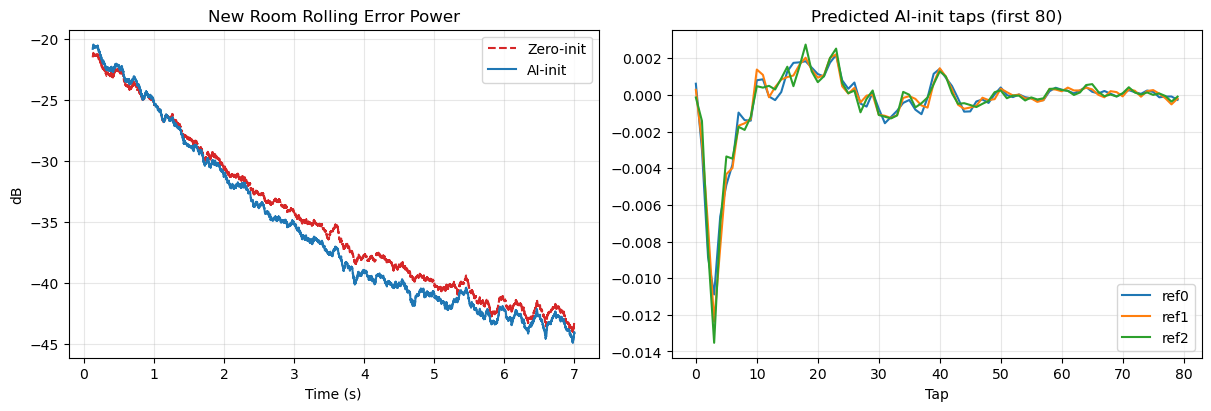

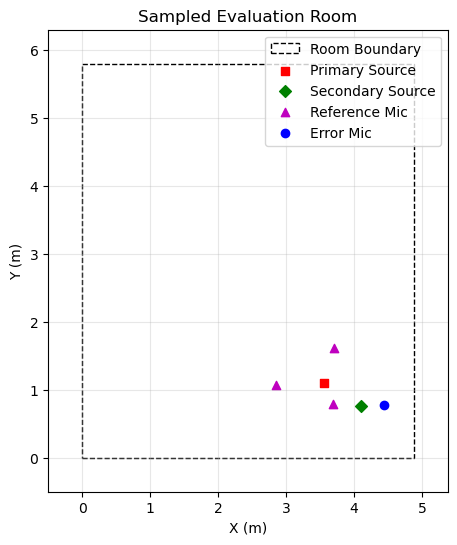

In [7]:
rng = np.random.default_rng(20260331)
sampler = build_mod.AcousticScenarioSampler(cfg, rng)
sampled = sampler.sample()
mgr = sampler.build_manager(sampled)
mgr.build(verbose=False)

noise, t = wn_gen(fs=cfg.fs, duration=cfg.noise_duration_s, f_low=cfg.f_low, f_high=cfg.f_high, rng=np.random.default_rng(20260331 + 1))
source_signal = _normalize_columns(noise)
time_axis = np.asarray(t[:, 0], dtype=float)
d = mgr.calculate_desired_signal(source_signal, len(time_axis))
x = mgr.calculate_reference_signal(source_signal, len(time_axis))
x = _normalize_columns(x)

start_idx = _resolve_feature_window_start(len(x), cfg)
X_ref = x[start_idx : start_idx + cfg.ref_window_samples, : cfg.num_reference_mics].T.astype(np.float32)
feat_proc = build_mod.FeatureProcessor(cfg)
gcc = feat_proc.compute_gcc_phat(X_ref)
psd = feat_proc.compute_psd_features(X_ref[0])
x_p = np.vstack([gcc, psd.reshape(1, -1)]).astype(np.float32)

sec_id = int(sampler.sec_ids[0])
err_id = int(sampler.err_ids[0])
s_path = np.asarray(mgr.get_secondary_rir(sec_id, err_id), dtype=np.float32)
e2r_paths = np.asarray(mgr.compute_transfer_rirs(sampled["err_positions"][0], sampled["ref_positions"]), dtype=np.float32)
s2r_paths = np.asarray(mgr.compute_transfer_rirs(sampled["sec_positions"][0], sampled["ref_positions"]), dtype=np.float32)
x_s_raw = _build_feature_vector(s_path, e2r_paths, s2r_paths, keep_meta)

x_p_model = standardize_array(x_p, x_p_stats["mean"], x_p_stats["std"])
x_s_model = standardize_array(x_s_raw, x_s_stats["mean"], x_s_stats["std"])
x_s_model = x_s_projector.transform(x_s_model)

with torch.no_grad():
    pred_latent = model(
        torch.from_numpy(x_p_model).unsqueeze(0).to(device=device, dtype=torch.float32),
        torch.from_numpy(x_s_model).unsqueeze(0).to(device=device, dtype=torch.float32),
    )
    pred_latent_np = pred_latent.cpu().numpy().reshape(-1)
    pred_yz = y_projector.inverse_np(pred_latent_np)
    pred_raw = destandardize_array(pred_yz, y_stats["mean"], y_stats["std"])
    W_AI_init = _target_to_w_full(pred_raw, cfg.num_reference_mics, keep_meta["w_keep_len"], cfg.filter_len)

mu = float(cfg.mu_candidates[0])
params = {
    "time": time_axis,
    "rir_manager": mgr,
    "L": int(cfg.filter_len),
    "mu": mu,
    "reference_signal": x,
    "desired_signal": d,
    "verbose": False,
    "normalized_update": bool(cfg.anc_normalized_update),
    "norm_epsilon": float(cfg.anc_norm_epsilon),
}
res_zero = cfxlms_fn(params)
res_ai = cfxlms_with_init(time_axis, mgr, int(cfg.filter_len), mu, x, d, w_init=W_AI_init, normalized_update=bool(cfg.anc_normalized_update), norm_epsilon=float(cfg.anc_norm_epsilon))

e_zero = np.asarray(res_zero["err_hist"], dtype=float)[:, 0]
e_ai = np.asarray(res_ai["err_hist"], dtype=float)[:, 0]
window_samples = min(max(500, int(round(0.125 * cfg.fs))), int(len(time_axis) // 2))
t_zero, db_zero = _rolling_mse_db(e_zero, int(cfg.fs), window_samples=window_samples)
t_ai, db_ai = _rolling_mse_db(e_ai, int(cfg.fs), window_samples=window_samples)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(t_zero, db_zero, label="Zero-init", color="tab:red", linestyle="--")
axes[0].plot(t_ai, db_ai, label="AI-init", color="tab:blue")
axes[0].set_title("New Room Rolling Error Power")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("dB")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(W_AI_init[0, 0, :80], label="ref0")
axes[1].plot(W_AI_init[0, 1, :80], label="ref1")
axes[1].plot(W_AI_init[0, 2, :80], label="ref2")
axes[1].set_title("Predicted AI-init taps (first 80)")
axes[1].set_xlabel("Tap")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.show()
plt.close(fig)

fig2, ax2 = plt.subplots(figsize=(7, 6))
mgr.plot_layout_2d(ax=ax2)
plt.title("Sampled Evaluation Room")
plt.show()
plt.close(fig2)




## Training-room replay: Zero-init vs HDF5-opt vs AI-init



training rooms: [0, 1, 2]


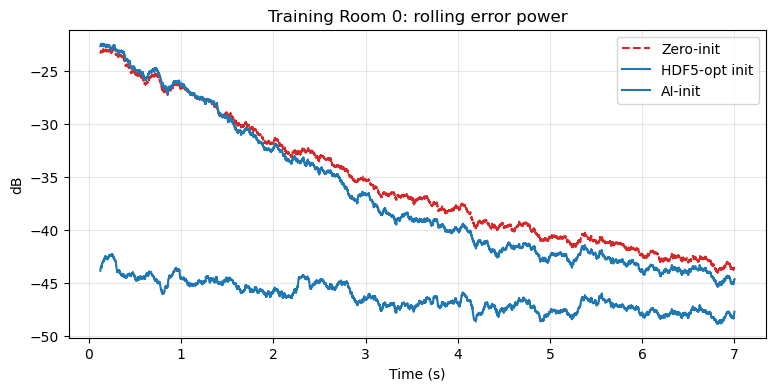

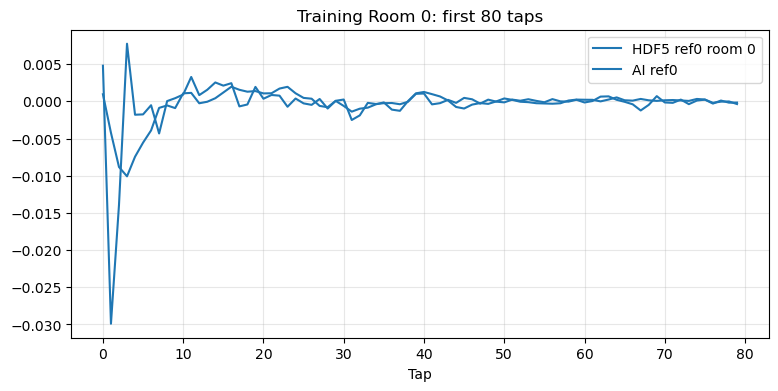

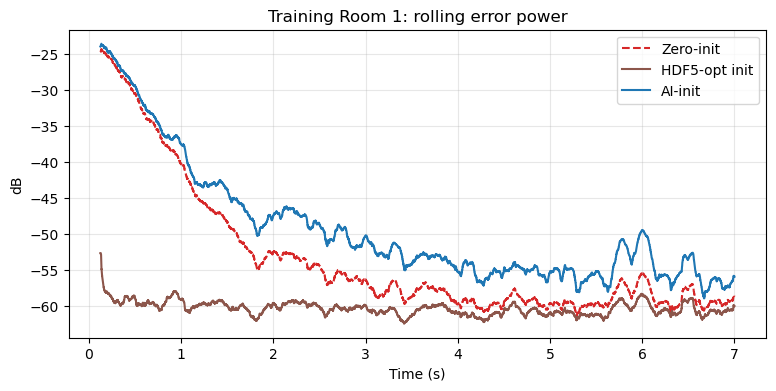

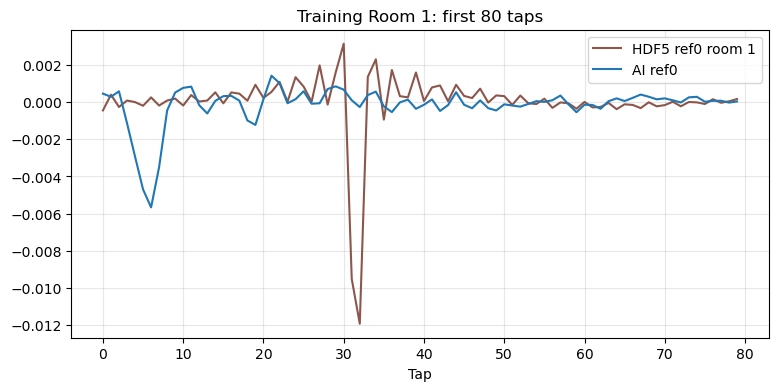

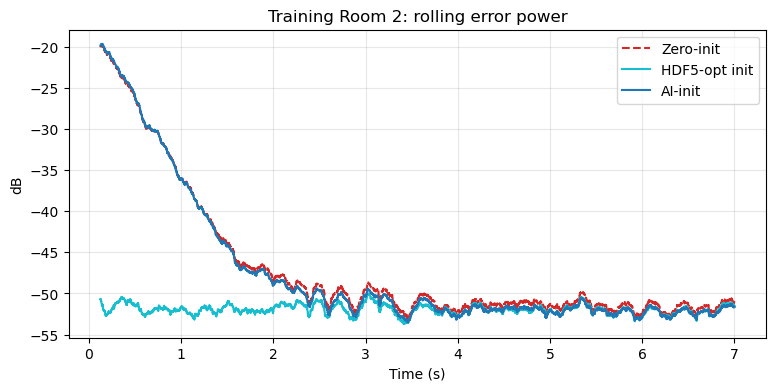

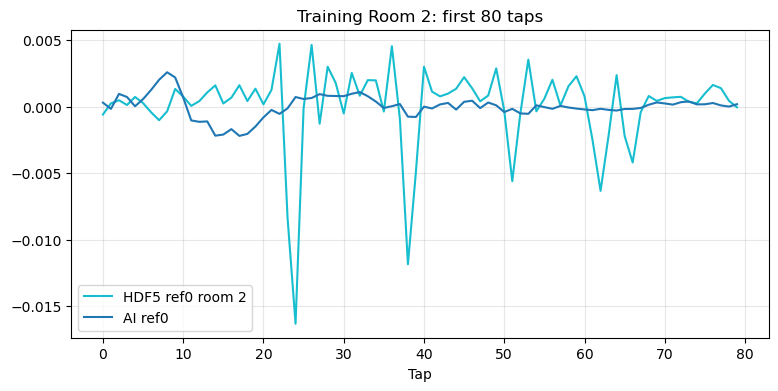

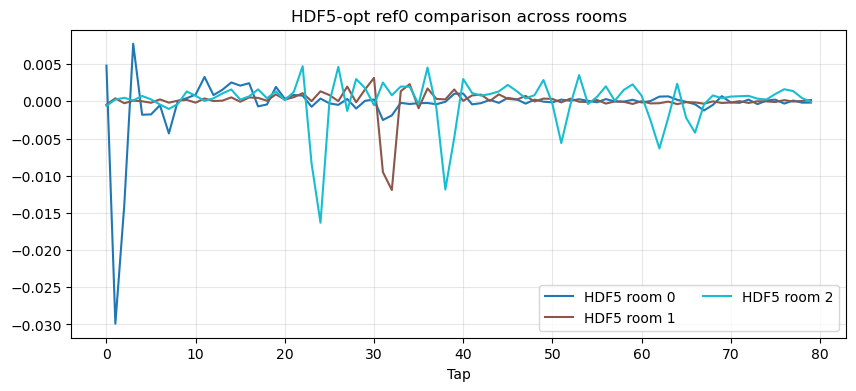

In [8]:
ROOMS = "first:3"
combined_weight_curves = []
with h5py.File(str(h5_path), "r") as hf:
    n_rooms = int(hf["raw/W_full"].shape[0])
    indices = _parse_indices(ROOMS, n_rooms)
    print("training rooms:", indices)
    room_colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(indices), 1)))
    for color, idx in zip(room_colors, indices):
        rp = "raw/room_params"
        sampled_i = {
            "room_size": np.asarray(hf[f"{rp}/room_size"][idx], dtype=float),
            "source_pos": np.asarray(hf[f"{rp}/source_position"][idx], dtype=float),
            "ref_positions": np.asarray(hf[f"{rp}/ref_positions"][idx], dtype=float),
            "sec_positions": np.asarray(hf[f"{rp}/sec_positions"][idx], dtype=float),
            "err_positions": np.asarray(hf[f"{rp}/err_positions"][idx], dtype=float),
            "sound_speed": float(hf[f"{rp}/sound_speed"][idx]),
            "absorption": float(hf[f"{rp}/material_absorption"][idx]),
            "image_order": int(hf[f"{rp}/image_source_order"][idx]),
        }
        mgr_i = sampler.build_manager(sampled_i)
        mgr_i.build(verbose=False)

        source_seed = int(hf["raw/qc_metrics/source_seed"][idx])
        noise_i, t_i = wn_gen(fs=cfg.fs, duration=cfg.noise_duration_s, f_low=cfg.f_low, f_high=cfg.f_high, rng=np.random.default_rng(source_seed))
        source_signal_i = _normalize_columns(noise_i)
        time_axis_i = np.asarray(t_i[:, 0], dtype=float)
        d_i = mgr_i.calculate_desired_signal(source_signal_i, len(time_axis_i))
        x_i = mgr_i.calculate_reference_signal(source_signal_i, len(time_axis_i))
        x_i = _normalize_columns(x_i)

        gcc_i = np.asarray(hf["processed/gcc_phat"][idx], dtype=np.float32)
        psd_i = np.asarray(hf["processed/psd_features"][idx], dtype=np.float32)
        x_p_i = np.vstack([gcc_i, psd_i.reshape(1, -1)]).astype(np.float32)
        x_s_i_raw = np.asarray(hf["processed/path_features"][idx], dtype=np.float32)
        x_p_i_model = standardize_array(x_p_i, x_p_stats["mean"], x_p_stats["std"])
        x_s_i_model = standardize_array(x_s_i_raw, x_s_stats["mean"], x_s_stats["std"])
        x_s_i_model = x_s_projector.transform(x_s_i_model)

        with torch.no_grad():
            pred_i = model(
                torch.from_numpy(x_p_i_model).unsqueeze(0).to(device=device, dtype=torch.float32),
                torch.from_numpy(x_s_i_model).unsqueeze(0).to(device=device, dtype=torch.float32),
            )
            pred_i_np = pred_i.cpu().numpy().reshape(-1)
            pred_i_yz = y_projector.inverse_np(pred_i_np)
            pred_i_raw = destandardize_array(pred_i_yz, y_stats["mean"], y_stats["std"])
            W_AI_i = _target_to_w_full(pred_i_raw, cfg.num_reference_mics, keep_meta["w_keep_len"], cfg.filter_len)

        W_H5_i = np.asarray(hf["raw/W_full"][idx], dtype=np.float32)
        params_i = {
            "time": time_axis_i,
            "rir_manager": mgr_i,
            "L": int(cfg.filter_len),
            "mu": mu,
            "reference_signal": x_i,
            "desired_signal": d_i,
            "verbose": False,
            "normalized_update": bool(cfg.anc_normalized_update),
            "norm_epsilon": float(cfg.anc_norm_epsilon),
        }
        e_zero_i = np.asarray(cfxlms_fn(params_i)["err_hist"], dtype=float)[:, 0]
        e_ai_i = np.asarray(cfxlms_with_init(time_axis_i, mgr_i, int(cfg.filter_len), mu, x_i, d_i, w_init=W_AI_i, normalized_update=bool(cfg.anc_normalized_update), norm_epsilon=float(cfg.anc_norm_epsilon))["err_hist"], dtype=float)[:, 0]
        e_h5_i = np.asarray(cfxlms_with_init(time_axis_i, mgr_i, int(cfg.filter_len), mu, x_i, d_i, w_init=W_H5_i, normalized_update=bool(cfg.anc_normalized_update), norm_epsilon=float(cfg.anc_norm_epsilon))["err_hist"], dtype=float)[:, 0]

        t0_i, db_zero_i = _rolling_mse_db(e_zero_i, int(cfg.fs), window_samples=window_samples)
        _, db_ai_i = _rolling_mse_db(e_ai_i, int(cfg.fs), window_samples=window_samples)
        _, db_h5_i = _rolling_mse_db(e_h5_i, int(cfg.fs), window_samples=window_samples)

        fig_room, ax_room = plt.subplots(figsize=(9, 4))
        ax_room.plot(t0_i, db_zero_i, label="Zero-init", color="tab:red", linestyle="--")
        ax_room.plot(t0_i, db_h5_i, label="HDF5-opt init", color=color)
        ax_room.plot(t0_i, db_ai_i, label="AI-init", color="tab:blue")
        ax_room.set_title(f"Training Room {idx}: rolling error power")
        ax_room.set_xlabel("Time (s)")
        ax_room.set_ylabel("dB")
        ax_room.grid(True, alpha=0.3)
        ax_room.legend()
        plt.show()
        plt.close(fig_room)

        fig_w, ax_w = plt.subplots(figsize=(9, 4))
        ax_w.plot(W_H5_i[0, 0, :80], label=f"HDF5 ref0 room {idx}", color=color)
        ax_w.plot(W_AI_i[0, 0, :80], label="AI ref0", color="tab:blue")
        ax_w.set_title(f"Training Room {idx}: first 80 taps")
        ax_w.set_xlabel("Tap")
        ax_w.grid(True, alpha=0.3)
        ax_w.legend()
        plt.show()
        plt.close(fig_w)

        combined_weight_curves.append((idx, color, W_H5_i[0, 0, :80].copy(), W_AI_i[0, 0, :80].copy()))

if combined_weight_curves:
    fig_comb, ax_comb = plt.subplots(figsize=(10, 4))
    for idx, color, w_h5_ref0, _ in combined_weight_curves:
        ax_comb.plot(w_h5_ref0, color=color, label=f"HDF5 room {idx}")
    ax_comb.set_title("HDF5-opt ref0 comparison across rooms")
    ax_comb.set_xlabel("Tap")
    ax_comb.grid(True, alpha=0.3)
    ax_comb.legend(ncols=2)
    plt.show()
    plt.close(fig_comb)



**2026-03-31 Update**
- Evaluation now uses the same `x_s` PCA projector and target PCA projector saved by training.
- AI initialization is reconstructed from decoded raw truncated `W` targets, exactly matching the updated train path.
- Cross-room HDF5-opt comparison remains multi-color so different rooms are visually separable.
